<a href="https://colab.research.google.com/github/kthanikonda/Privacy-Aware-Computing/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install textstat

In [ ]:
import requests
import re
import numpy as np
import nltk
import spacy
import gensim.downloader as api
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from transformers import pipeline
import textstat
from sentence_transformers import SentenceTransformer, util
import pandas as pd

In [ ]:
# Download necessary resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")  # Load spaCy model for Named Entity Recognition (NER)
stopwords = set(nltk.corpus.stopwords.words("english"))  # Load stopwords

# Load Word2Vec Model for Semantic Similarity
word_vectors = api.load("glove-wiki-gigaword-50")  # Use GloVe embeddings

# Initialize sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis")

# Initialize semantic similarity model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [ ]:
# Step 1: Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# URLs for Google and LinkedIn Privacy Policies
google_privacy_policy_url = "https://policies.google.com/privacy"
linkedin_privacy_policy_url = "https://www.linkedin.com/legal/privacy-policy"

# Fetch policies
google_text = extract_privacy_policy(google_privacy_policy_url)
linkedin_text = extract_privacy_policy(linkedin_privacy_policy_url)

In [ ]:
# Step 2: DP-Based Text Sanitization Functions
def replace_named_entities(text):
    doc = nlp(text)
    modified_text = text
    entity_replacements = []
    for ent in doc.ents:
        if ent.label_ == "ORG":
            modified_text = modified_text.replace(ent.text, "The Company")
            entity_replacements.append((ent.text, "The Company"))
        elif ent.label_ == "GPE":
            modified_text = modified_text.replace(ent.text, "The Location")
            entity_replacements.append((ent.text, "The Location"))
        elif ent.label_ in ["DATE", "TIME", "DURATION"]:
            modified_text = modified_text.replace(ent.text, "<DATE>")
            entity_replacements.append((ent.text, "<DATE>"))
    return modified_text, entity_replacements

In [ ]:
def get_filtered_similar_words(word, k=5, similarity_threshold=0.75):
    try:
        similar_words = word_vectors.most_similar(word, topn=k)
        filtered_words = [w[0] for w in similar_words if w[1] >= similarity_threshold]
        return filtered_words if filtered_words else [word]
    except KeyError:
        return [word]

In [ ]:
def dp_word_substitute(text, epsilon=1.0, k=5, similarity_threshold=0.75):
    words = word_tokenize(text)
    new_words = []
    word_changes = []

    for word in words:
        if word.lower() in stopwords:
            new_words.append(word)
            continue

        candidates = get_filtered_similar_words(word, k, similarity_threshold)
        if len(candidates) > 1:
            # Implement Exponential Mechanism (Instead of selecting the most similar word)
            scores = np.array([word_vectors.similarity(word, w) for w in candidates])
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))

            replacement = np.random.choice(candidates, p=probabilities)
            if replacement != word:
                word_changes.append((word, replacement))
            new_words.append(replacement)
        else:
            new_words.append(word)

    return " ".join(new_words), word_changes

In [ ]:
def shuffle_sentences(text, epsilon=0.5):
    sentences = sent_tokenize(text)
    noise = np.random.laplace(0, 1/epsilon, len(sentences))
    shuffled_sentences = [x for _, x in sorted(zip(noise, sentences))]
    sentence_changes = list(zip(sentences, shuffled_sentences))
    return " ".join(shuffled_sentences), sentence_changes

In [ ]:
# Add Controlled Laplace Noise
def add_laplace_noise(text, epsilon=0.5):
    def replace_number(match):
        number = int(match.group(0))
        noise = np.random.laplace(0, 1/epsilon)
        noisy_number = max(1, int(number + noise))
        return str(noisy_number)
    modified_text = re.sub(r"\b\d+\b", replace_number, text)
    return modified_text

In [ ]:
# Sentiment Analysis
def calculate_sentiment(text):
    sentences = sent_tokenize(text)
    sentiment_scores = [sentiment_analyzer(sentence)[0]['score'] for sentence in sentences]
    avg_sentiment = np.mean(sentiment_scores)
    return avg_sentiment

In [ ]:
# Deception Score Calculation
def calculate_deception_score(text):
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return clarity_score, deception_score

In [ ]:
# Privacy Leakage Analysis
def calculate_privacy_leakage(original_text, sanitized_text):
    similarity_score = util.pytorch_cos_sim(
        semantic_model.encode(original_text, convert_to_tensor=True),
        semantic_model.encode(sanitized_text, convert_to_tensor=True)
    ).item()
    return similarity_score

In [ ]:
# Apply Improved DP-Based Transformations with Enhanced Clarity
google_sanitized, google_entity_changes = replace_named_entities(google_text)
google_sanitized, google_word_changes = dp_word_substitute(google_sanitized, epsilon=1.0, k=5, similarity_threshold=0.75)
google_sanitized, google_sentence_changes = shuffle_sentences(google_sanitized, epsilon=0.5)
google_sanitized = add_laplace_noise(google_sanitized, epsilon=0.5)

linkedin_sanitized, linkedin_entity_changes = replace_named_entities(linkedin_text)
linkedin_sanitized, linkedin_word_changes = dp_word_substitute(linkedin_sanitized, epsilon=1.0, k=5, similarity_threshold=0.75)
linkedin_sanitized, linkedin_sentence_changes = shuffle_sentences(linkedin_sanitized, epsilon=0.5)
linkedin_sanitized = add_laplace_noise(linkedin_sanitized, epsilon=0.5)


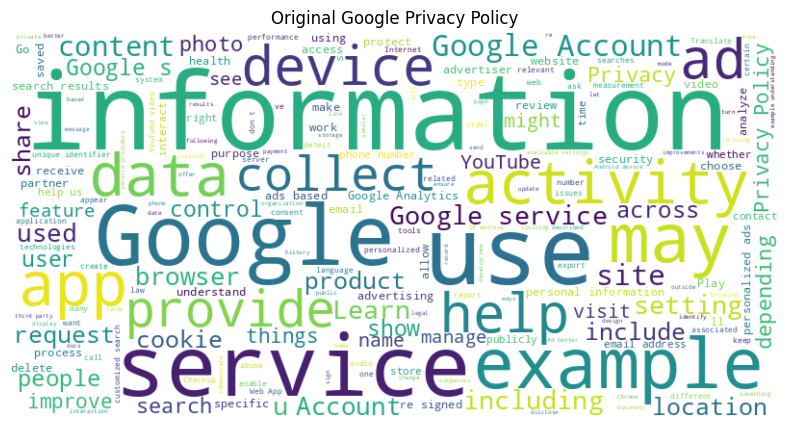

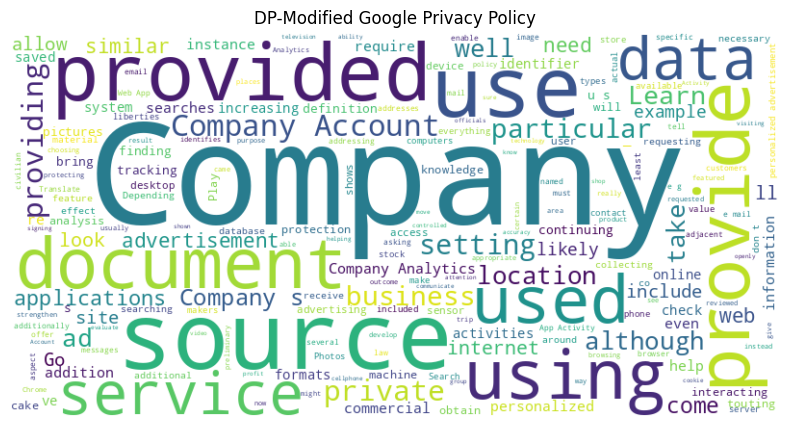

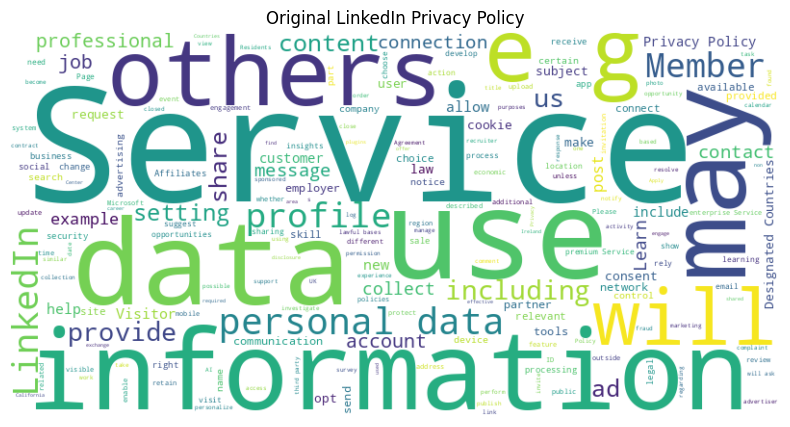

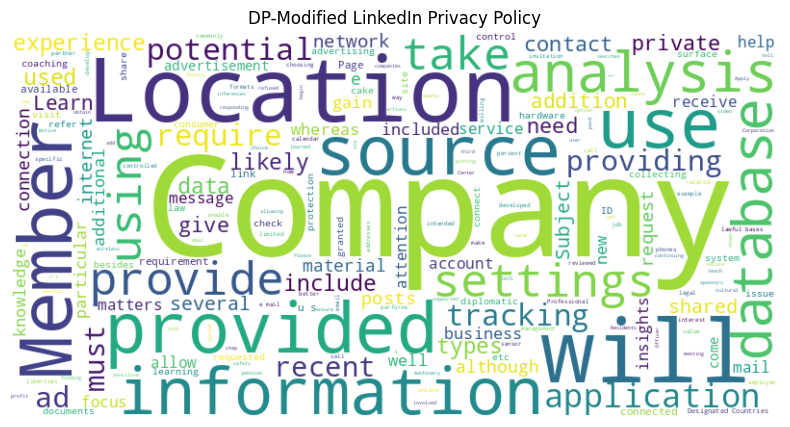

In [ ]:
# Word Cloud Visualization
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate Word Clouds for Original and Sanitized Texts
generate_wordcloud(google_text, "Original Google Privacy Policy")
generate_wordcloud(google_sanitized, "DP-Modified Google Privacy Policy")

generate_wordcloud(linkedin_text, "Original LinkedIn Privacy Policy")
generate_wordcloud(linkedin_sanitized, "DP-Modified LinkedIn Privacy Policy")


In [ ]:
# Collect Scores for Visualization
scores_data = []

for name, original_text, sanitized_text in [
    ("Google", google_text, google_sanitized),
    ("LinkedIn", linkedin_text, linkedin_sanitized)
]:
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)

    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    privacy_leakage_score = calculate_privacy_leakage(original_text, sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
        "Privacy Leakage": privacy_leakage_score
    })

# Create DataFrame for Visualization
scores_df = pd.DataFrame(scores_data)
print(scores_df)

     Policy  Original Clarity  Sanitized Clarity  Original Deception  \
0    Google             40.18               9.63             241.374   
1  LinkedIn             40.08              13.48             145.444   

   Sanitized Deception  Original Sentiment  Sanitized Sentiment  \
0              145.759            0.927001             0.951802   
1              101.064            0.924182             0.938945   

   Privacy Leakage  
0         0.545901  
1         0.320741  


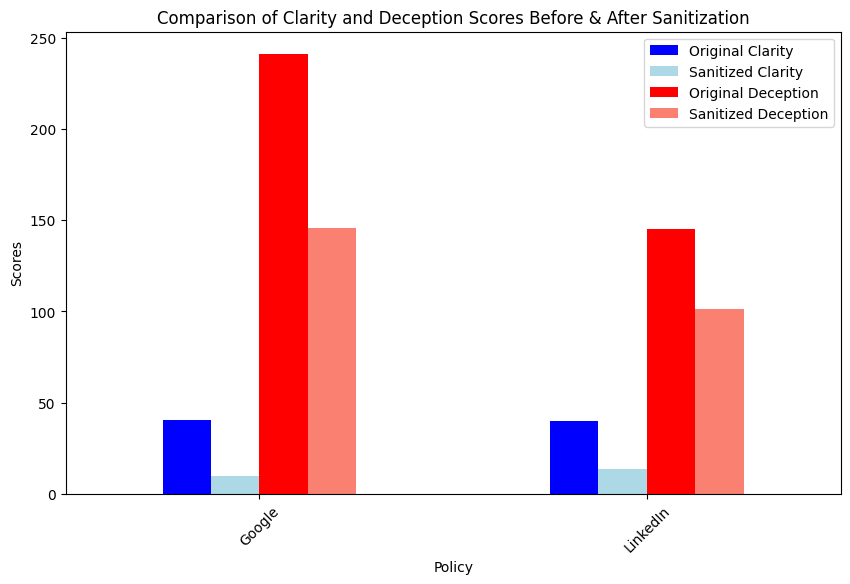

In [ ]:
# Visualization: Clarity and Deception Scores
scores_df.set_index("Policy")[[
    "Original Clarity", "Sanitized Clarity",
    "Original Deception", "Sanitized Deception"
]].plot(kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon'])
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

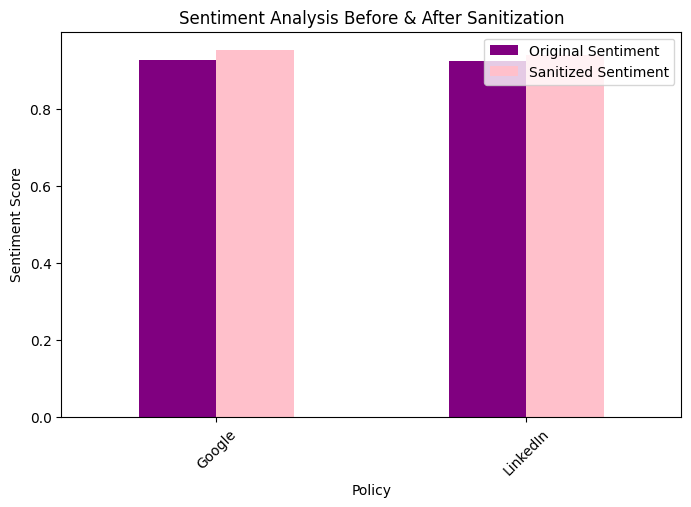

In [ ]:
# Visualization: Sentiment Analysis
scores_df.set_index("Policy")[[
    "Original Sentiment", "Sanitized Sentiment"
]].plot(kind='bar', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

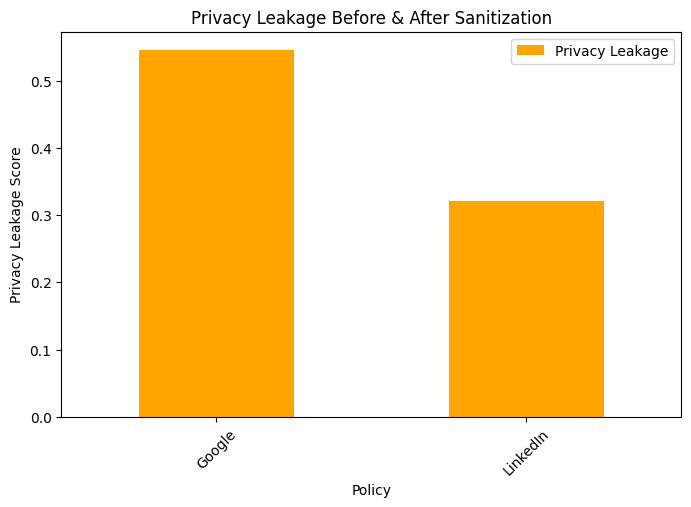

In [ ]:
# Visualization: Privacy Leakage Analysis
scores_df.set_index("Policy")[["Privacy Leakage"]].plot(kind='bar', figsize=(8, 5), color='orange')
plt.ylabel("Privacy Leakage Score")
plt.title("Privacy Leakage Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import requests
import re
import numpy as np
import nltk
import spacy
import gensim.downloader as api
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from transformers import pipeline
import textstat
from sentence_transformers import SentenceTransformer, util
import pandas as pd

In [ ]:
# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")  # Load spaCy model for Named Entity Recognition (NER)
stopwords = set(nltk.corpus.stopwords.words("english"))  # Load stopwords

# Load Word2Vec Model for Semantic Similarity
word_vectors = api.load("glove-wiki-gigaword-50")  # Use GloVe embeddings

# Initialize sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis")

# Initialize semantic similarity model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [ ]:
# Step 1: Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# URLs for Google and LinkedIn Privacy Policies
google_privacy_policy_url = "https://policies.google.com/privacy"
linkedin_privacy_policy_url = "https://www.linkedin.com/legal/privacy-policy"

# Fetch policies
google_text = extract_privacy_policy(google_privacy_policy_url)
linkedin_text = extract_privacy_policy(linkedin_privacy_policy_url)


In [ ]:
# Step 2: DP-Based Text Sanitization Functions
def replace_named_entities(text):
    doc = nlp(text)
    modified_text = text
    entity_replacements = []
    for ent in doc.ents:
        if ent.label_ == "ORG":
            modified_text = modified_text.replace(ent.text, "The Company")
            entity_replacements.append((ent.text, "The Company"))
        elif ent.label_ == "GPE":
            modified_text = modified_text.replace(ent.text, "The Location")
            entity_replacements.append((ent.text, "The Location"))
        elif ent.label_ in ["DATE", "TIME", "DURATION"]:
            modified_text = modified_text.replace(ent.text, "<DATE>")
            entity_replacements.append((ent.text, "<DATE>"))
    return modified_text, entity_replacements



In [ ]:
def get_filtered_similar_words(word, k=5, similarity_threshold=0.75):
    try:
        similar_words = word_vectors.most_similar(word, topn=k)
        filtered_words = [w[0] for w in similar_words if w[1] >= similarity_threshold]
        return filtered_words if filtered_words else [word]
    except KeyError:
        return [word]

In [ ]:
def dp_word_substitute(text, epsilon=0.5, k=5, similarity_threshold=0.75):
    words = word_tokenize(text)
    new_words = []
    word_changes = []

    for word in words:
        if word.lower() in stopwords:
            new_words.append(word)
            continue

        candidates = get_filtered_similar_words(word, k, similarity_threshold)
        if len(candidates) > 1:
            # Implement Exponential Mechanism with improved word selection
            scores = np.array([word_vectors.similarity(word, w) for w in candidates])
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))

            replacement = np.random.choice(candidates, p=probabilities)
            if replacement != word:
                word_changes.append((word, replacement))
            new_words.append(replacement)
        else:
            new_words.append(word)

    return " ".join(new_words), word_changes

In [ ]:
def shuffle_sentences(text, epsilon=0.3):  # Reduced epsilon to limit excessive shuffling
    sentences = sent_tokenize(text)
    noise = np.random.laplace(0, 1/epsilon, len(sentences))
    shuffled_sentences = [x for _, x in sorted(zip(noise, sentences))]
    sentence_changes = list(zip(sentences, shuffled_sentences))
    return " ".join(shuffled_sentences), sentence_changes

In [ ]:
# Add Controlled Laplace Noise with Reduced Impact
def add_laplace_noise(text, epsilon=0.2):  # Reduced Laplace noise for less distortion
    def replace_number(match):
        number = int(match.group(0))
        noise = np.random.laplace(0, 1/epsilon)
        noisy_number = max(1, int(number + noise))
        return str(noisy_number)
    modified_text = re.sub(r"\b\d+\b", replace_number, text)
    return modified_text

In [ ]:
# Sentiment Analysis
def calculate_sentiment(text):
    sentences = sent_tokenize(text)
    sentiment_scores = [sentiment_analyzer(sentence)[0]['score'] for sentence in sentences]
    avg_sentiment = np.mean(sentiment_scores)
    return avg_sentiment

In [ ]:
# Deception Score Calculation
def calculate_deception_score(text):
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return clarity_score, deception_score


In [ ]:
# Privacy Leakage Analysis
def calculate_privacy_leakage(original_text, sanitized_text):
    similarity_score = util.pytorch_cos_sim(
        semantic_model.encode(original_text, convert_to_tensor=True),
        semantic_model.encode(sanitized_text, convert_to_tensor=True)
    ).item()
    return similarity_score

In [ ]:
# Apply Improved DP-Based Transformations with Enhanced Clarity
google_sanitized, google_entity_changes = replace_named_entities(google_text)
google_sanitized, google_word_changes = dp_word_substitute(google_sanitized, epsilon=0.5, k=5, similarity_threshold=0.8)
google_sanitized, google_sentence_changes = shuffle_sentences(google_sanitized, epsilon=0.3)
google_sanitized = add_laplace_noise(google_sanitized, epsilon=0.2)

linkedin_sanitized, linkedin_entity_changes = replace_named_entities(linkedin_text)
linkedin_sanitized, linkedin_word_changes = dp_word_substitute(linkedin_sanitized, epsilon=0.5, k=5, similarity_threshold=0.8)
linkedin_sanitized, linkedin_sentence_changes = shuffle_sentences(linkedin_sanitized, epsilon=0.3)
linkedin_sanitized = add_laplace_noise(linkedin_sanitized, epsilon=0.2)




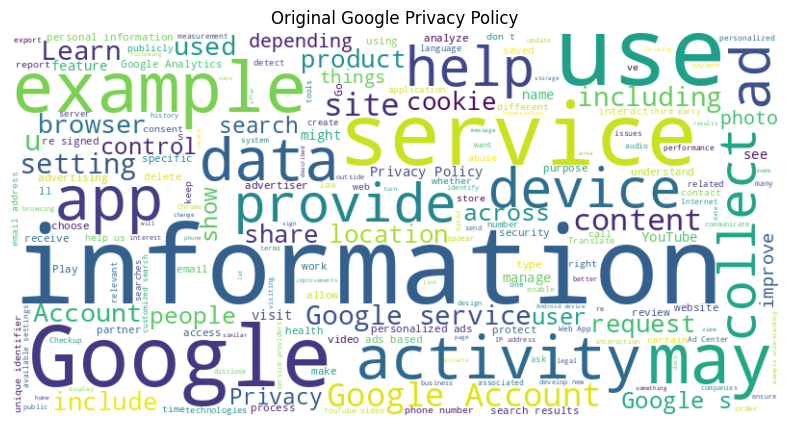

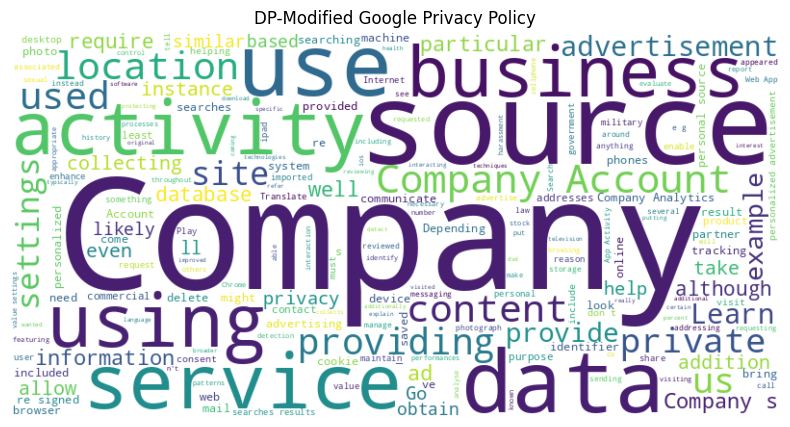

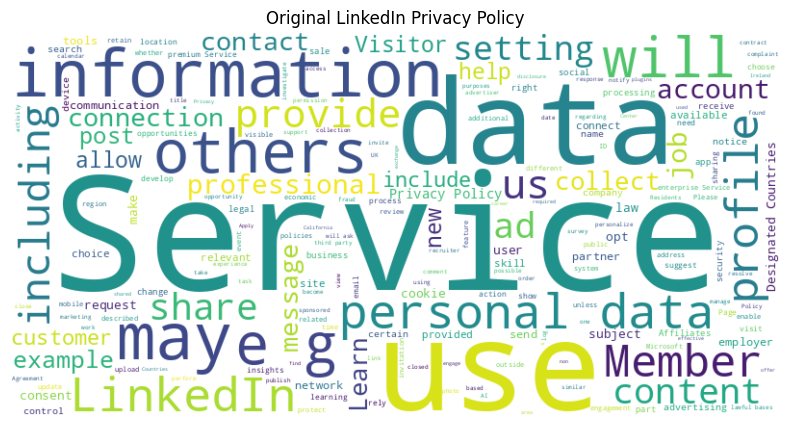

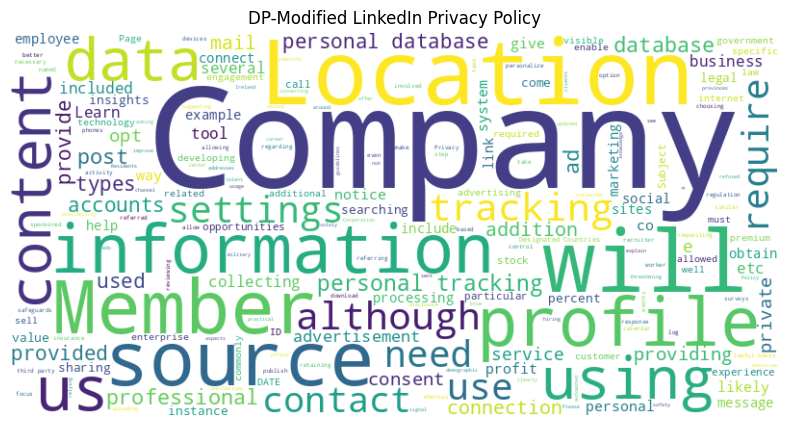

In [ ]:
# Word Cloud Visualization
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Generate Word Clouds for Original and Sanitized Texts
generate_wordcloud(google_text, "Original Google Privacy Policy")
generate_wordcloud(google_sanitized, "DP-Modified Google Privacy Policy")

generate_wordcloud(linkedin_text, "Original LinkedIn Privacy Policy")
generate_wordcloud(linkedin_sanitized, "DP-Modified LinkedIn Privacy Policy")

In [ ]:
# Collect Scores for Visualization
scores_data = []

for name, original_text, sanitized_text in [
    ("Google", google_text, google_sanitized),
    ("LinkedIn", linkedin_text, linkedin_sanitized)
]:
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)

    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    privacy_leakage_score = calculate_privacy_leakage(original_text, sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
        "Privacy Leakage": privacy_leakage_score
    })

# Create DataFrame for Visualization
scores_df = pd.DataFrame(scores_data)
print(scores_df)


     Policy  Original Clarity  Sanitized Clarity  Original Deception  \
0    Google             40.18               2.52             241.374   
1  LinkedIn             40.08               6.58             145.444   

   Sanitized Deception  Original Sentiment  Sanitized Sentiment  \
0              161.236            0.927001             0.973715   
1              105.894            0.924182             0.937220   

   Privacy Leakage  
0         0.575820  
1         0.401327  


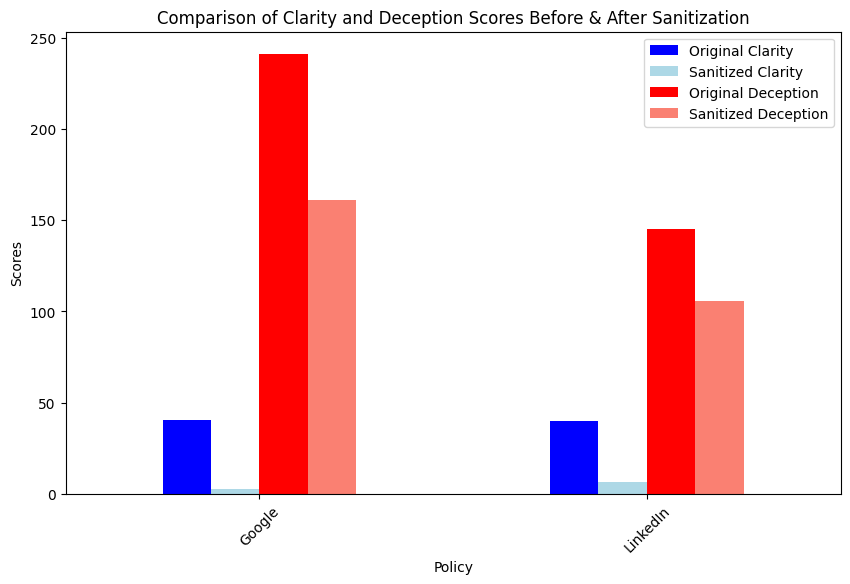

In [ ]:
# Visualization: Clarity and Deception Scores
scores_df.set_index("Policy")[[
    "Original Clarity", "Sanitized Clarity",
    "Original Deception", "Sanitized Deception"
]].plot(kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon'])
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

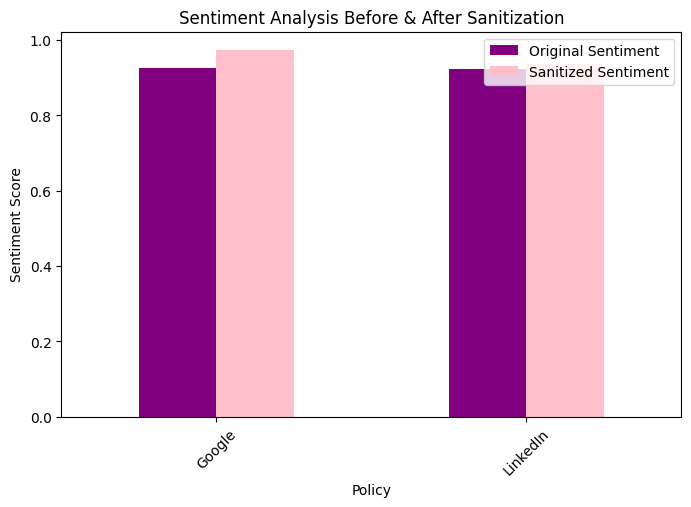

In [ ]:
# Visualization: Sentiment Analysis
scores_df.set_index("Policy")[["Original Sentiment", "Sanitized Sentiment"]].plot(kind='bar', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

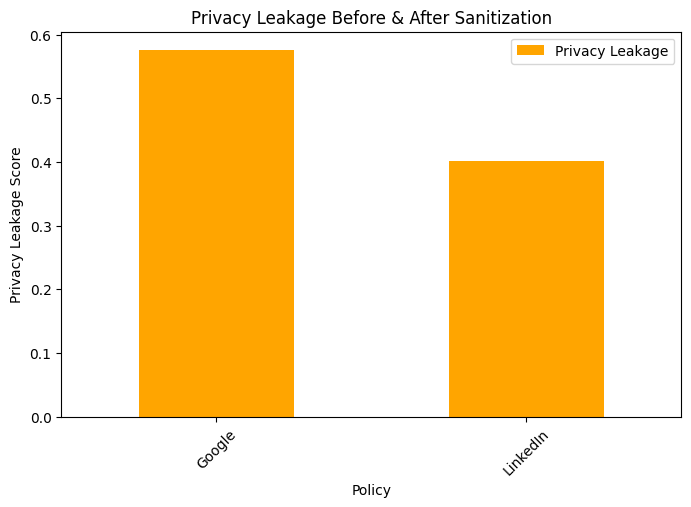

In [ ]:
# Visualization: Privacy Leakage Analysis
scores_df.set_index("Policy")[["Privacy Leakage"]].plot(kind='bar', figsize=(8, 5), color='orange')
plt.ylabel("Privacy Leakage Score")
plt.title("Privacy Leakage Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import requests
import re
import numpy as np
import nltk
import spacy
import gensim.downloader as api
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from transformers import pipeline
import textstat
from sentence_transformers import SentenceTransformer, util
import pandas as pd
from nltk.corpus import wordnet


In [ ]:
# Download necessary resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nlp = spacy.load("en_core_web_sm")  # Load spaCy model for Named Entity Recognition (NER)
stopwords = set(nltk.corpus.stopwords.words("english"))  # Load stopwords

# Load Word2Vec Model for Semantic Similarity
word_vectors = api.load("glove-wiki-gigaword-50")  # Use GloVe embeddings

# Initialize sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis")

# Initialize semantic similarity model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [ ]:
# Step 1: Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# URLs for Google and LinkedIn Privacy Policies
google_privacy_policy_url = "https://policies.google.com/privacy"
linkedin_privacy_policy_url = "https://www.linkedin.com/legal/privacy-policy"

# Fetch policies
google_text = extract_privacy_policy(google_privacy_policy_url)
linkedin_text = extract_privacy_policy(linkedin_privacy_policy_url)

In [ ]:
# Step 2: DP-Based Text Sanitization Functions
def replace_named_entities(text):
    doc = nlp(text)
    modified_text = text
    entity_replacements = []
    for ent in doc.ents:
        if ent.label_ == "ORG":
            modified_text = modified_text.replace(ent.text, "The Company")
            entity_replacements.append((ent.text, "The Company"))
        elif ent.label_ == "GPE":
            modified_text = modified_text.replace(ent.text, "The Location")
            entity_replacements.append((ent.text, "The Location"))
        elif ent.label_ in ["DATE", "TIME", "DURATION"]:
            modified_text = modified_text.replace(ent.text, "<DATE>")
            entity_replacements.append((ent.text, "<DATE>"))
    return modified_text, entity_replacements

In [ ]:
# Function to get similarity between two words using GloVe embeddings
def get_similarity(word1, word2):
    try:
        # Get the vector representation of the words
        vector1 = word_vectors[word1]
        vector2 = word_vectors[word2]

        # Calculate and return the cosine similarity
        similarity = 1 - cosine(vector1, vector2)
        return similarity
    except KeyError:
        # If one of the words is not in the vocabulary, return a low similarity score
        return 0.0


In [ ]:
# Function to get semantically similar candidates
def get_semantic_candidates(word, k=5):
    try:
        # Find the top-k most similar words to the input word
        similar_words = word_vectors.most_similar(word, topn=k)
        # Extract just the words from the results (ignoring the similarity scores)
        candidates = [similar_word[0] for similar_word in similar_words]
        return candidates
    except KeyError:
        # If the word is not in the model's vocabulary, return an empty list
        return []

In [ ]:
def dp_word_substitute(text, epsilon, k, similarity_threshold, mode="default"):
    word_changes = []
    words = text.split()  # Assuming splitting by spaces for simplicity

    for word in words:
        # Find semantically similar candidates (this part needs to be implemented)
        candidates = get_semantic_candidates(word, k)  # This function is hypothetical

        # Filter candidates based on similarity threshold
        candidates = [w for w in candidates if get_similarity(word, w) >= similarity_threshold]

        if candidates:  # Only proceed if there are candidates
            if mode == "random":
                probabilities = [get_probability(w) for w in candidates]
                replacement = np.random.choice(candidates, p=probabilities)
            else:
                replacement = candidates[0]  # Default to the first candidate or original word
            if replacement != word:
                word_changes.append((word, replacement))
        else:
            word_changes.append((word, word))  # If no candidates, retain the original word

    # Reconstruct the sanitized text
    sanitized_text = " ".join([change[1] for change in word_changes])
    return sanitized_text, word_changes


In [ ]:
def shuffle_sentences(text, epsilon=0.5):
    sentences = sent_tokenize(text)
    noise = np.random.laplace(0, 1/epsilon, len(sentences))
    shuffled_sentences = [x for _, x in sorted(zip(noise, sentences))]
    sentence_changes = list(zip(sentences, shuffled_sentences))
    return " ".join(shuffled_sentences), sentence_changes

In [ ]:
# Add Controlled Laplace Noise
def add_laplace_noise(text, epsilon=0.5):
    def replace_number(match):
        number = int(match.group(0))
        noise = np.random.laplace(0, 1/epsilon)
        noisy_number = max(1, int(number + noise))
        return str(noisy_number)
    modified_text = re.sub(r"\b\d+\b", replace_number, text)
    return modified_text

In [ ]:
# Sentiment Analysis
def calculate_sentiment(text):
    sentences = sent_tokenize(text)
    sentiment_scores = [sentiment_analyzer(sentence)[0]['score'] for sentence in sentences]
    avg_sentiment = np.mean(sentiment_scores)
    return avg_sentiment

In [ ]:
# Deception Score Calculation
def calculate_deception_score(text):
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return clarity_score, deception_score

In [ ]:
# Privacy Leakage Analysis
def calculate_privacy_leakage(original_text, sanitized_text):
    similarity_score = util.pytorch_cos_sim(
        semantic_model.encode(original_text, convert_to_tensor=True),
        semantic_model.encode(sanitized_text, convert_to_tensor=True)
    ).item()
    return similarity_score

In [ ]:
# Apply Improved DP-Based Transformations with Enhanced Clarity
google_sanitized, google_entity_changes = replace_named_entities(google_text)
google_sanitized, google_word_changes = dp_word_substitute(google_sanitized, epsilon=1.0, k=5, similarity_threshold=0.75)
google_sanitized, google_sentence_changes = shuffle_sentences(google_sanitized, epsilon=0.5)
google_sanitized = add_laplace_noise(google_sanitized, epsilon=0.5)

linkedin_sanitized, linkedin_entity_changes = replace_named_entities(linkedin_text)
linkedin_sanitized, linkedin_word_changes = dp_word_substitute(linkedin_sanitized, epsilon=1.0, k=5, similarity_threshold=0.75)
linkedin_sanitized, linkedin_sentence_changes = shuffle_sentences(linkedin_sanitized, epsilon=0.5)
linkedin_sanitized = add_laplace_noise(linkedin_sanitized, epsilon=0.5)

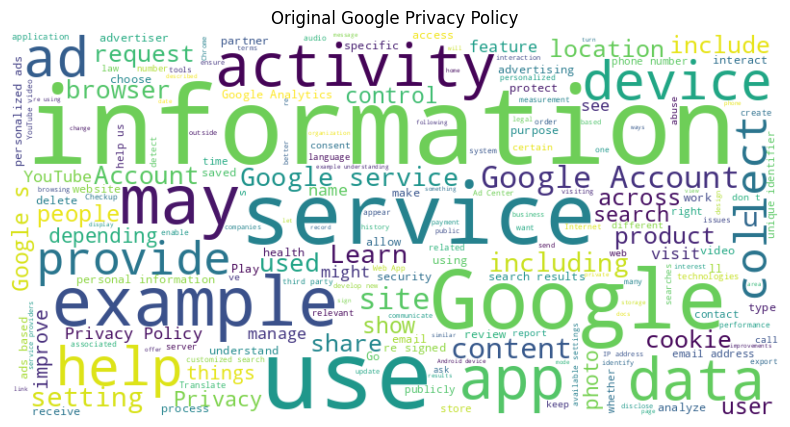

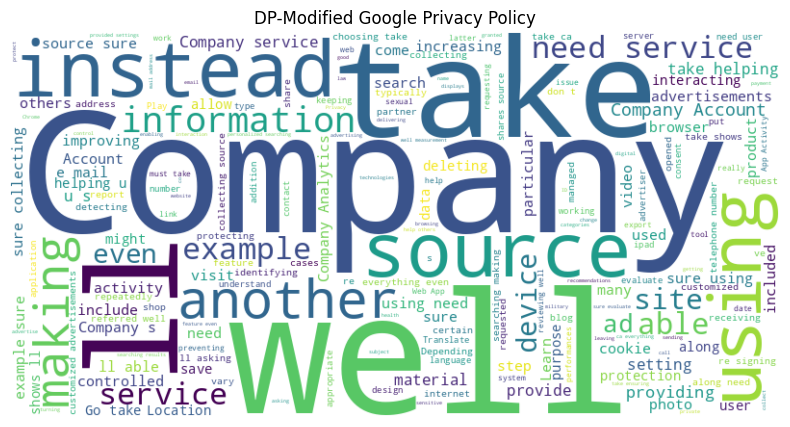

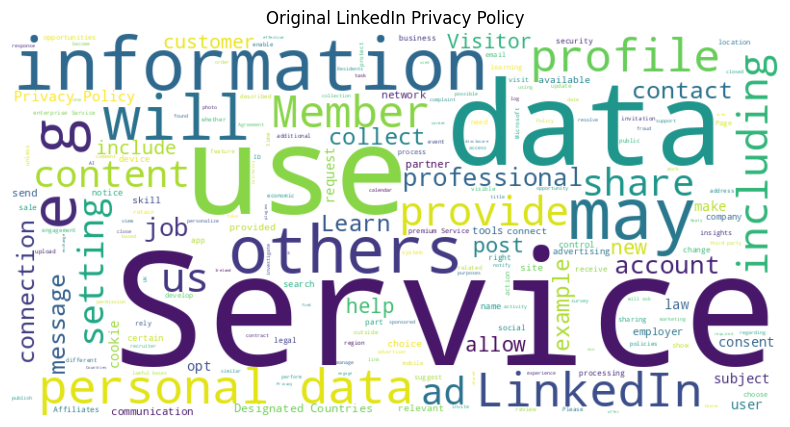

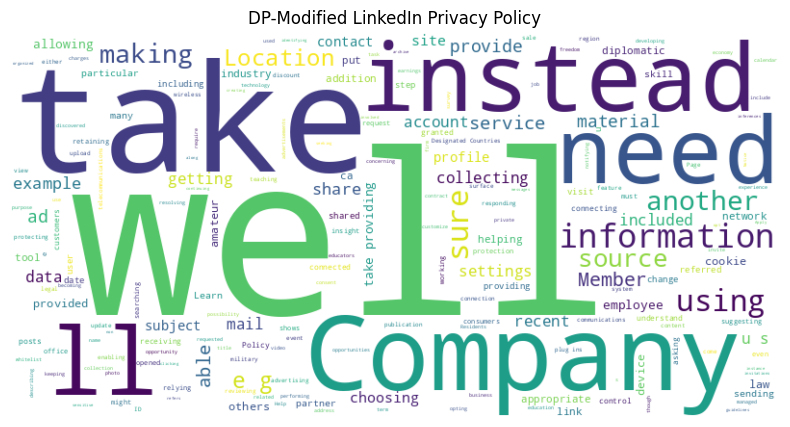

In [ ]:
# Word Cloud Visualization
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate Word Clouds for Original and Sanitized Texts
generate_wordcloud(google_text, "Original Google Privacy Policy")
generate_wordcloud(google_sanitized, "DP-Modified Google Privacy Policy")

generate_wordcloud(linkedin_text, "Original LinkedIn Privacy Policy")
generate_wordcloud(linkedin_sanitized, "DP-Modified LinkedIn Privacy Policy")

In [ ]:
# Collect Scores for Visualization
scores_data = []

for name, original_text, sanitized_text in [
    ("Google", google_text, google_sanitized),
    ("LinkedIn", linkedin_text, linkedin_sanitized)
]:
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)

    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    privacy_leakage_score = calculate_privacy_leakage(original_text, sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
        "Privacy Leakage": privacy_leakage_score
    })

# Create DataFrame for Visualization
scores_df = pd.DataFrame(scores_data)
print(scores_df)

     Policy  Original Clarity  Sanitized Clarity  Original Deception  \
0    Google             40.18              32.33             241.374   
1  LinkedIn             40.08              32.73             145.444   

   Sanitized Deception  Original Sentiment  Sanitized Sentiment  \
0              158.369            0.927001             0.951407   
1               84.589            0.924182             0.948137   

   Privacy Leakage  
0         0.481421  
1         0.348589  


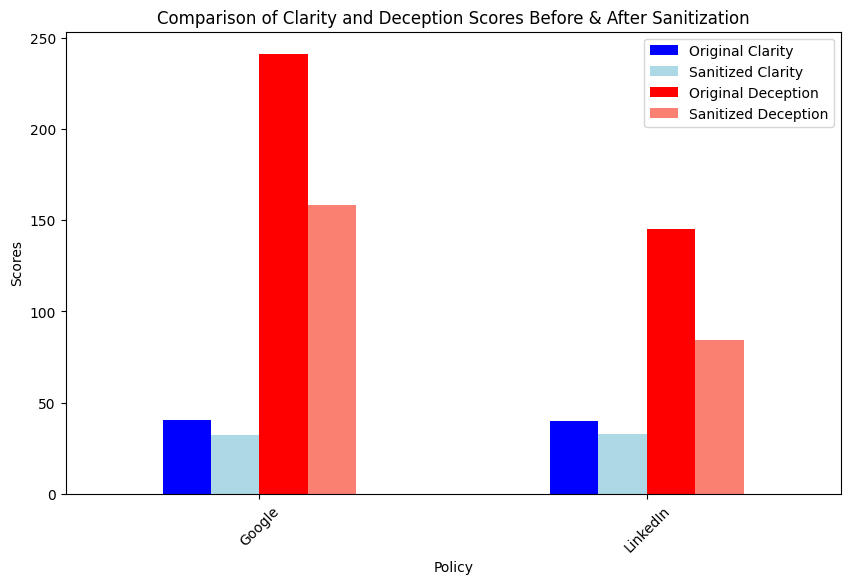

In [ ]:
# Visualization: Clarity and Deception Scores
scores_df.set_index("Policy")[[
    "Original Clarity", "Sanitized Clarity",
    "Original Deception", "Sanitized Deception"
]].plot(kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon'])
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

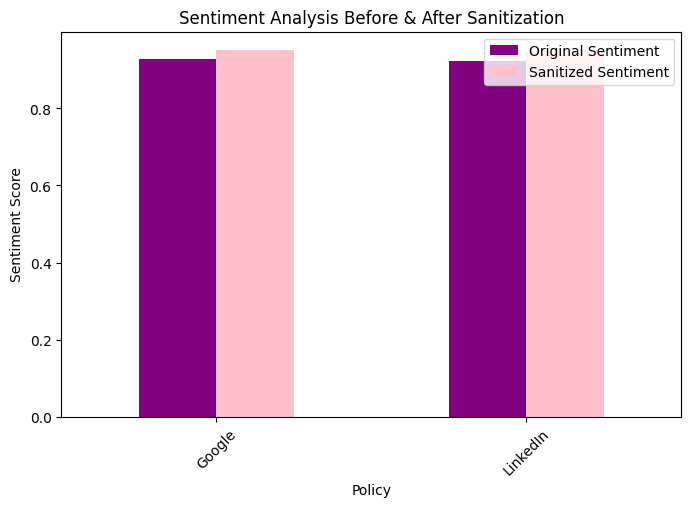

In [ ]:
# Visualization: Sentiment Analysis
scores_df.set_index("Policy")[[
    "Original Sentiment", "Sanitized Sentiment"
]].plot(kind='bar', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

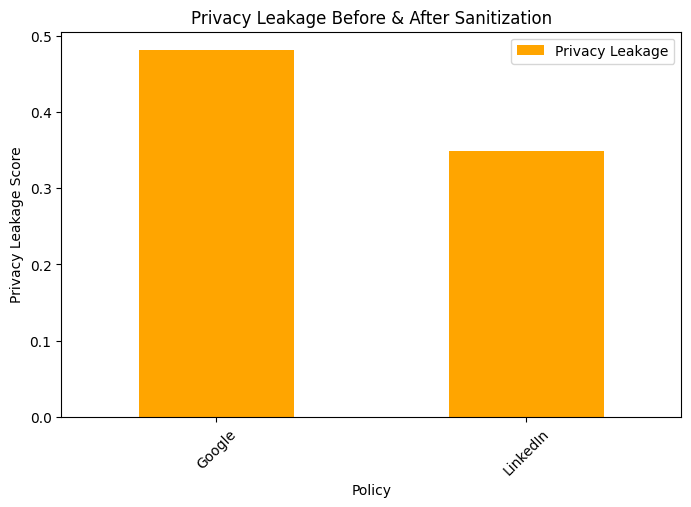

In [ ]:
# Visualization: Privacy Leakage Analysis
scores_df.set_index("Policy")[["Privacy Leakage"]].plot(kind='bar', figsize=(8, 5), color='orange')
plt.ylabel("Privacy Leakage Score")
plt.title("Privacy Leakage Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import requests
import re
import numpy as np
import nltk
import spacy
import gensim.downloader as api
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from transformers import pipeline
import textstat
from sentence_transformers import SentenceTransformer, util
import pandas as pd
from nltk.corpus import wordnet


In [ ]:
# Download necessary resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nlp = spacy.load("en_core_web_sm")  # Load spaCy model for Named Entity Recognition (NER)
stopwords = set(nltk.corpus.stopwords.words("english"))  # Load stopwords

# Load Word2Vec Model for Semantic Similarity
word_vectors = api.load("glove-wiki-gigaword-50")  # Use GloVe embeddings

# Initialize sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis")

# Initialize semantic similarity model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [ ]:
# Step 1: Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# URLs for Google and LinkedIn Privacy Policies
google_privacy_policy_url = "https://policies.google.com/privacy"
linkedin_privacy_policy_url = "https://www.linkedin.com/legal/privacy-policy"

# Fetch policies
google_text = extract_privacy_policy(google_privacy_policy_url)
linkedin_text = extract_privacy_policy(linkedin_privacy_policy_url)

In [ ]:
# Function to replace named entities
def replace_named_entities(text):
    doc = nlp(text)
    modified_text = text
    entity_replacements = []
    for ent in doc.ents:
        if ent.label_ == "ORG":
            # Keep original organization names to maintain clarity
            modified_text = modified_text.replace(ent.text, "<Organization>")
            entity_replacements.append((ent.text, "<Organization>"))
        elif ent.label_ == "GPE":
            modified_text = modified_text.replace(ent.text, "<Location>")
            entity_replacements.append((ent.text, "<Location>"))
        elif ent.label_ in ["DATE", "TIME", "DURATION"]:
            modified_text = modified_text.replace(ent.text, "<DATE>")
            entity_replacements.append((ent.text, "<DATE>"))
    return modified_text, entity_replacements

In [ ]:
# Function to get similarity between words using GloVe embeddings
def get_similarity(word1, word2):
    try:
        vector1 = word_vectors[word1]
        vector2 = word_vectors[word2]
        similarity = 1 - cosine(vector1, vector2)
        return similarity
    except KeyError:
        return 0.0

In [ ]:
# Function to get semantically similar candidates
def get_semantic_candidates(word, k=5):
    try:
        similar_words = word_vectors.most_similar(word, topn=k)
        candidates = [similar_word[0] for similar_word in similar_words]
        return candidates
    except KeyError:
        return []

In [ ]:
# Function to substitute words with enhanced clarity
def dp_word_substitute_enhanced(text, epsilon, k, similarity_threshold, mode="default"):
    word_changes = []
    words = text.split()

    for word in words:
        # Get semantic candidates for the word
        candidates = get_semantic_candidates(word, k)

        # Filter candidates based on similarity threshold
        candidates = [w for w in candidates if get_similarity(word, w) >= similarity_threshold]

        if candidates:
            # Default mode, select the best candidate (highest similarity)
            replacement = candidates[0]  # Choose the most similar word

            # Only replace if the word has changed
            if replacement != word:
                word_changes.append((word, replacement))
        else:
            word_changes.append((word, word))  # Retain the original word if no candidate

    # Reconstruct the sanitized text
    sanitized_text = " ".join([change[1] for change in word_changes])
    return sanitized_text, word_changes

In [ ]:
# Function to add minimal Laplace noise for clarity
def add_minimal_laplace_noise(text, epsilon=0.2):  # Reduced epsilon for clarity
    def replace_number(match):
        number = int(match.group(0))
        noise = np.random.laplace(0, 1/epsilon)
        noisy_number = max(1, int(number + noise))
        return str(noisy_number)
    modified_text = re.sub(r"\b\d+\b", replace_number, text)
    return modified_text

In [ ]:
# Function to calculate Deception Score
def calculate_deception_score(text):
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return clarity_score, deception_score

In [ ]:
# Function to sanitize text with enhanced clarity
def sanitize_for_clarity_enhanced(text):
    sanitized_text, entity_replacements = replace_named_entities(text)
    sanitized_text, word_changes = dp_word_substitute_enhanced(sanitized_text, epsilon=0.5, k=5, similarity_threshold=0.85)  # Improved similarity threshold
    sanitized_text = add_minimal_laplace_noise(sanitized_text, epsilon=0.2)  # Reduced Laplace noise

    # Calculate the clarity and deception score
    clarity_score, deception_score = calculate_deception_score(sanitized_text)

    return sanitized_text, clarity_score, deception_score

In [ ]:
# Sentiment Analysis
def calculate_sentiment(text):
    sentences = sent_tokenize(text)
    sentiment_scores = [sentiment_analyzer(sentence)[0]['score'] for sentence in sentences]
    avg_sentiment = np.mean(sentiment_scores)
    return avg_sentiment

In [ ]:
# Privacy Leakage Analysis
def calculate_privacy_leakage(original_text, sanitized_text):
    similarity_score = util.pytorch_cos_sim(
        semantic_model.encode(original_text, convert_to_tensor=True),
        semantic_model.encode(sanitized_text, convert_to_tensor=True)
    ).item()
    return similarity_score

In [ ]:
# Apply the enhanced sanitization process to Google and LinkedIn privacy policies
google_sanitized_enhanced, google_clarity, google_deception = sanitize_for_clarity_enhanced(google_text)
linkedin_sanitized_enhanced, linkedin_clarity, linkedin_deception = sanitize_for_clarity_enhanced(linkedin_text)


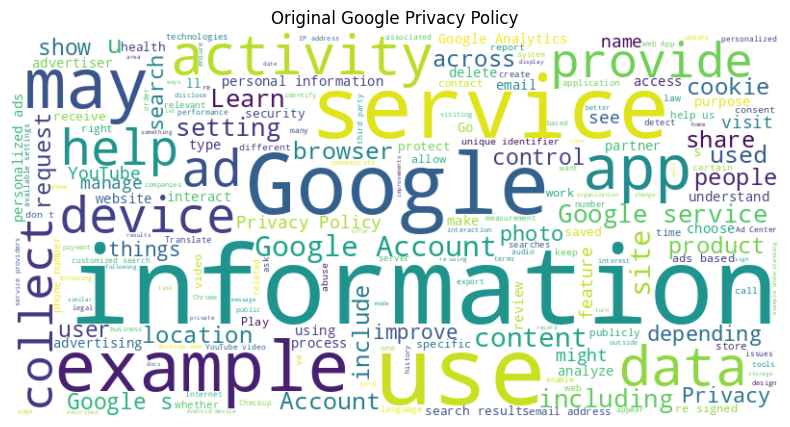

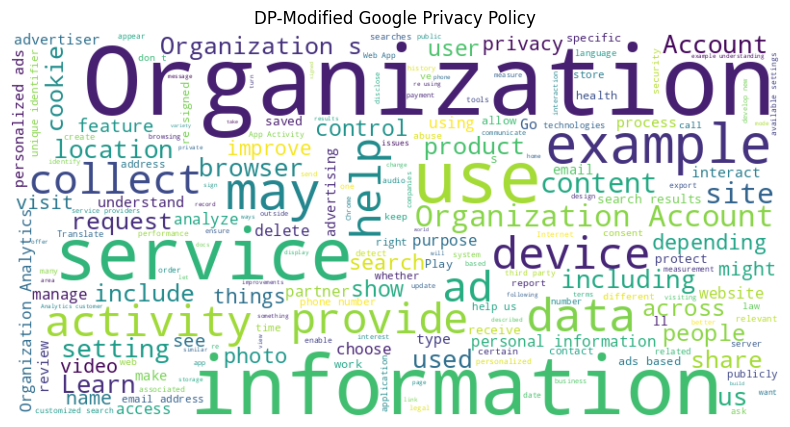

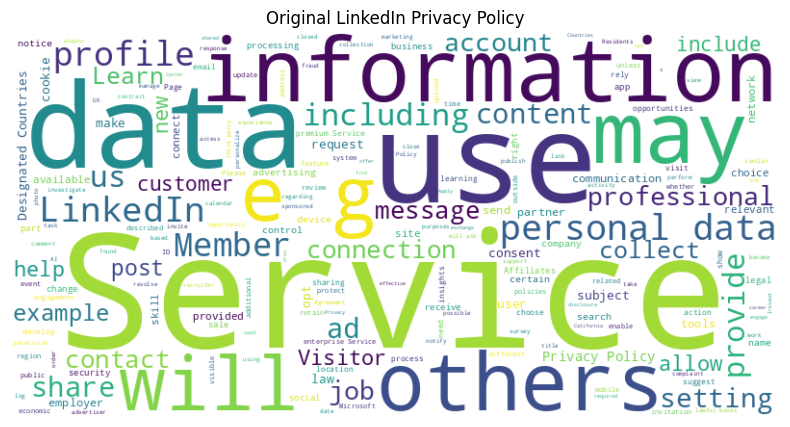

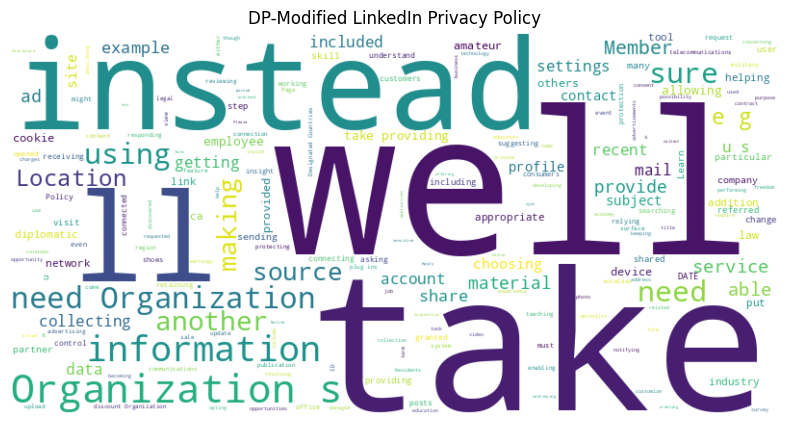

In [ ]:
# Word Cloud Visualization
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate Word Clouds for Original and Sanitized Texts
generate_wordcloud(google_text, "Original Google Privacy Policy")
generate_wordcloud(google_sanitized, "DP-Modified Google Privacy Policy")

generate_wordcloud(linkedin_text, "Original LinkedIn Privacy Policy")
generate_wordcloud(linkedin_sanitized, "DP-Modified LinkedIn Privacy Policy")

In [ ]:
# Visualization
scores_data_enhanced = []

for name, original_text, sanitized_text in [
    ("Google", google_text, google_sanitized_enhanced),
    ("LinkedIn", linkedin_text, linkedin_sanitized_enhanced)
]:
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)

    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    privacy_leakage_score = calculate_privacy_leakage(original_text, sanitized_text)

    scores_data_enhanced.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
        "Privacy Leakage": privacy_leakage_score
    })

# Create DataFrame for Visualization
scores_df_enhanced = pd.DataFrame(scores_data_enhanced)
print(scores_df_enhanced)


     Policy  Original Clarity  Sanitized Clarity  Original Deception  \
0    Google             40.18              16.32             241.374   
1  LinkedIn             40.08              24.88             145.444   

   Sanitized Deception  Original Sentiment  Sanitized Sentiment  \
0              166.576            0.927001             0.951113   
1               90.084            0.924182             0.952824   

   Privacy Leakage  
0         0.779204  
1         0.419261  


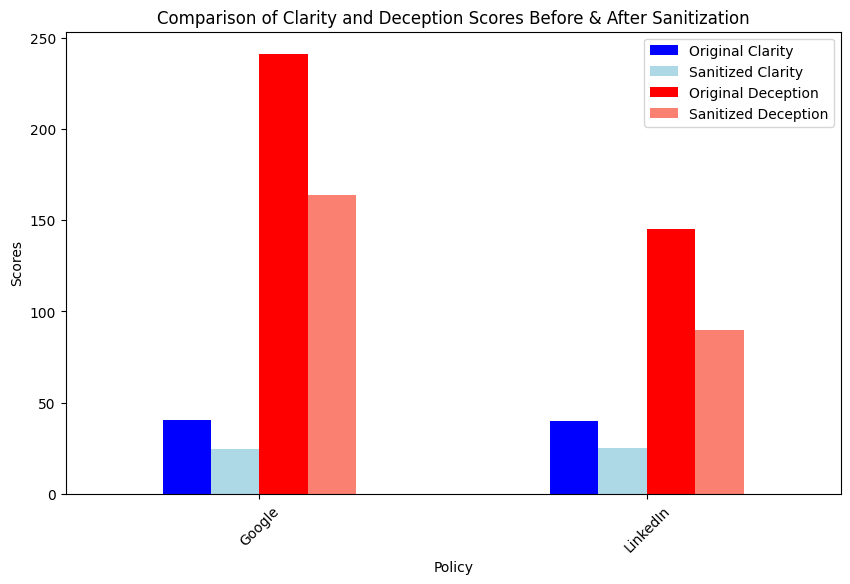

In [ ]:
# Visualization: Clarity and Deception Scores
scores_df.set_index("Policy")[[
    "Original Clarity", "Sanitized Clarity",
    "Original Deception", "Sanitized Deception"
]].plot(kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon'])
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

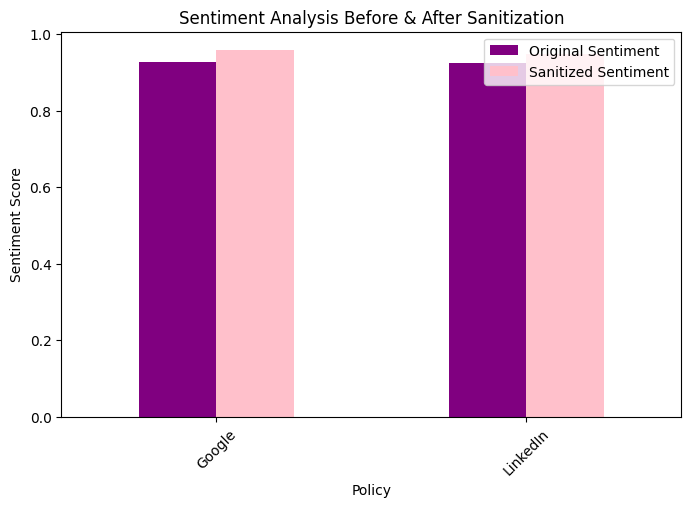

In [ ]:
# Visualization: Sentiment Analysis
scores_df.set_index("Policy")[[
    "Original Sentiment", "Sanitized Sentiment"
]].plot(kind='bar', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

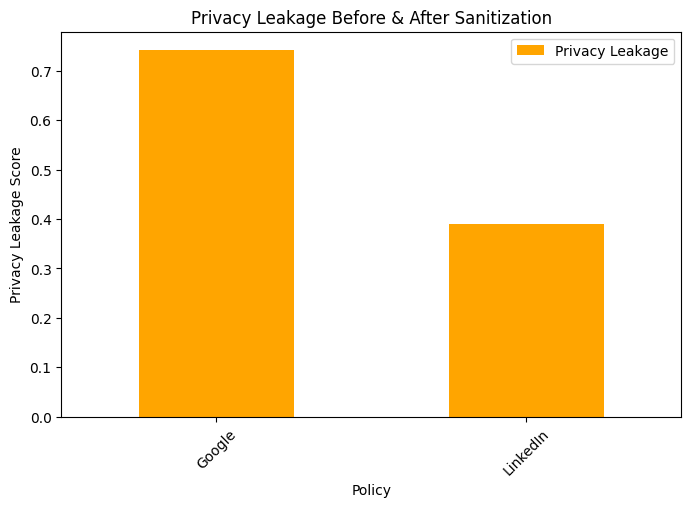

In [ ]:
# Visualization: Privacy Leakage Analysis
scores_df.set_index("Policy")[["Privacy Leakage"]].plot(kind='bar', figsize=(8, 5), color='orange')
plt.ylabel("Privacy Leakage Score")
plt.title("Privacy Leakage Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

In [2]:
! pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.6 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Word Changes for Google:
  'using' -> 'used'
  'using' -> 'use'
  'using' -> 'used'
  'using' -> 'used'
  'using' -> 'use'
  'using' -> 'use'
  'could' -> 'would'
  'know' -> 'tell'
  'could' -> 'would'
  'using' -> 'use'
  'could' -> 'would'
  'know' -> 'else'
  'could' -> 'would'
  'using' -> 'use'
  'could' -> 'would'
  'know' -> 'why'
  'could' -> 'would'
  'using' -> 'used'
  'get' -> 'getting'
  'get' -> 'getting'
  'using' -> 'use'
  'using' -> 'use'
  'else' -> 'nobody'
  'get' -> 'n't'
  'third' -> 'second'
  'using' -> 'used'
  'something' -> 'really'
  'know' -> 'n't'
  'sure' -> 'n't'
  'something' -> 'thing'
  'sure' -> 'we'
  '370' -> '380'
  'using' -> 'use'
  'using' -> 'used'
  'using' -> 'use'
  'using' -> 'use'
  'third' -> 'fourth'
  'third' -> 'second'
  'third' -> 'second'
  'even' -> 'so'
  '5' -> '7'
  'using' -> 'used'
  'something' -> 'what'
  'using' -> 'used'
  '3' -> '2'
  '1,000' -> '5,000'
  'although' -> 'though'
  'third' -> 'second'
  'still' -> 'but'

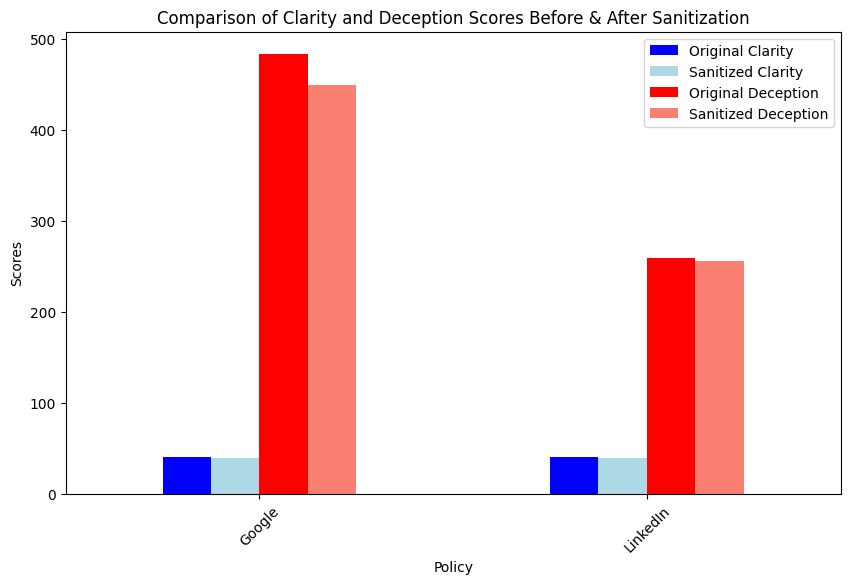

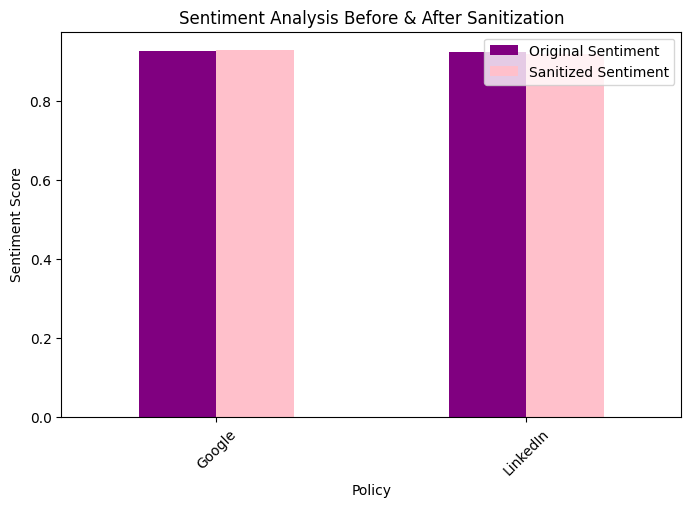

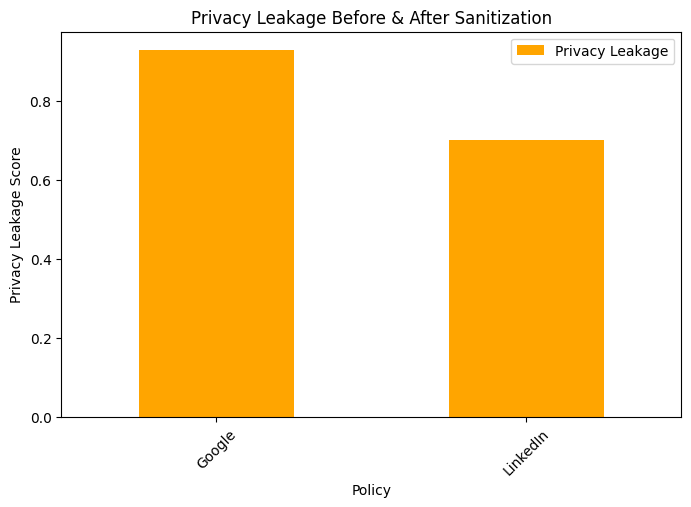

In [4]:
import requests
import re
import numpy as np
import nltk
import spacy
import gensim.downloader as api
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from transformers import pipeline
import textstat
from sentence_transformers import SentenceTransformer, util
import pandas as pd

# Download necessary resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")
stopwords = set(nltk.corpus.stopwords.words("english"))

# Load Word2Vec Model
word_vectors = api.load("glove-wiki-gigaword-50")

# Initialize sentiment analysis model
sentiment_analyzer = pipeline("sentiment-analysis")

# Initialize semantic similarity model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 1: Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    policy_text = " ".join([p.get_text() for p in paragraphs])
    return policy_text if policy_text else "Privacy Policy text not found."

# URLs for Google and LinkedIn Privacy Policies
google_privacy_policy_url = "https://policies.google.com/privacy"
linkedin_privacy_policy_url = "https://www.linkedin.com/legal/privacy-policy"

# Fetch policies
google_text = extract_privacy_policy(google_privacy_policy_url)
linkedin_text = extract_privacy_policy(linkedin_privacy_policy_url)

# Step 2: DP-Based Text Sanitization Functions
def replace_named_entities(text, allowed_labels=["ORG", "GPE"]):
    """Replaces named entities. Sensitivity = 1."""
    doc = nlp(text)
    modified_text = text
    entity_replacements = []
    for ent in doc.ents:
        if ent.label_ in allowed_labels:
            modified_text = modified_text.replace(ent.text, "The Company")
            entity_replacements.append((ent.text, "The Company"))
    return modified_text, entity_replacements

def get_filtered_similar_words(word, k=5, similarity_threshold=0.75):
    """Gets similar words. No DP here."""
    try:
        similar_words = word_vectors.most_similar(word, topn=k)
        filtered_words = [w[0] for w in similar_words if w[1] >= similarity_threshold]
        return filtered_words if filtered_words else [word]
    except KeyError:
        return [word]

def dp_word_substitute(text, epsilon=0.1, k=5, similarity_threshold=0.95):
    """Substitutes words, prioritizing clarity. Sensitivity assumed to be 1."""
    words = word_tokenize(text)
    new_words = []
    word_changes = []
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]

    for word in words:
        if word.lower() in stopwords:
            new_words.append(word)
            continue

        candidates = get_filtered_similar_words(word, k, similarity_threshold)

        # Prioritize clearer/less vague replacements
        if word.lower() in vague_words and len(candidates) > 0:
            # Look for clearer candidates
            clearer_candidates = [w for w in candidates if w.lower() not in vague_words]
            if clearer_candidates:
                replacement = clearer_candidates[0]  # Choose the "clearest"
                word_changes.append((word, replacement))
                new_words.append(replacement)
                continue

        if len(candidates) > 1:
            scores = np.array([word_vectors.similarity(word, w) for w in candidates])
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))

            replacement = np.random.choice(candidates, p=probabilities)
            if replacement != word:
                word_changes.append((word, replacement))
            new_words.append(replacement)
        else:
            new_words.append(word)

    return " ".join(new_words), word_changes

def preserve_logical_sentence_order(text):
    """Preserves sentence order. No DP here."""
    sentences = sent_tokenize(text)
    return " ".join(sentences)

def shuffle_sentences(text, epsilon=0.01):
    """Reduces epsilon significantly. Sensitivity is the number of sentences."""
    sentences = sent_tokenize(text)
    noise = np.random.laplace(0, 1/epsilon, len(sentences))
    shuffled_sentences = [x for _, x in sorted(zip(noise, sentences))]
    sentence_changes = list(zip(sentences, shuffled_sentences))
    return " ".join(shuffled_sentences), sentence_changes

def add_controlled_laplace_noise(text, epsilon=0.1, max_noise=3):
    """Reduces max_noise and epsilon."""
    def replace_number(match):
        number = int(match.group(0))
        noise = np.random.laplace(0, 1/epsilon)
        noisy_number = max(1, int(number + min(max_noise, abs(noise))))
        return str(noisy_number)
    modified_text = re.sub(r"\b\d+\b", replace_number, text)
    return modified_text

# Sentiment Analysis
def calculate_sentiment(text):
    """Calculates sentiment."""
    sentences = sent_tokenize(text)
    sentiment_scores = [sentiment_analyzer(sentence)[0]['score'] for sentence in sentences]
    avg_sentiment = np.mean(sentiment_scores)
    return avg_sentiment

# Deception Score Calculation
def calculate_deception_score(text):
    """Calculates deception score. Increased clarity weight."""
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.3 + (vague_word_count * 5) * 0.7 #Higher weight to vague words
    return clarity_score, deception_score

# Privacy Leakage Analysis
def calculate_privacy_leakage(original_text, sanitized_text):
    """Calculates privacy leakage."""
    similarity_score = util.pytorch_cos_sim(
        semantic_model.encode(original_text, convert_to_tensor=True),
        semantic_model.encode(sanitized_text, convert_to_tensor=True)
    ).item()
    return similarity_score

# Apply Improved DP-Based Transformations
google_sanitized, google_entity_changes = replace_named_entities(google_text, allowed_labels=["ORG", "GPE"])
linkedin_sanitized, linkedin_entity_changes = replace_named_entities(linkedin_text, allowed_labels=["ORG", "GPE"])

google_sanitized, google_word_changes = dp_word_substitute(google_sanitized, epsilon=0.1, k=5, similarity_threshold=0.95)
linkedin_sanitized, linkedin_word_changes = dp_word_substitute(linkedin_sanitized, epsilon=0.1, k=5, similarity_threshold=0.95)

google_sanitized = preserve_logical_sentence_order(google_sanitized)
linkedin_sanitized = preserve_logical_sentence_order(linkedin_sanitized)

google_sanitized = add_controlled_laplace_noise(google_sanitized, epsilon=0.1, max_noise=3)
linkedin_sanitized = add_controlled_laplace_noise(linkedin_sanitized, epsilon=0.1, max_noise=3)

# Collect Scores for Visualization
scores_data = []

for name, original_text, sanitized_text in [
    ("Google", google_text, google_sanitized),
    ("LinkedIn", linkedin_text, linkedin_sanitized)
]:
    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)

    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    privacy_leakage_score = calculate_privacy_leakage(original_text, sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
        "Privacy Leakage": privacy_leakage_score
    })

    # Print Word Changes
    print(f"\nWord Changes for {name}:")
    for original, replacement in google_word_changes if name == "Google" else linkedin_word_changes:
        print(f"  '{original}' -> '{replacement}'")

# Create DataFrame for Visualization
scores_df = pd.DataFrame(scores_data)
print(scores_df)

# Print a table for comparison
print("\nComparison Table:")
print(scores_df[["Policy", "Original Clarity", "Sanitized Clarity", "Original Deception", "Sanitized Deception"]])

# Identify some word changes to explain
print("\nExample Word Changes (Illustrative):")
if "LinkedIn" in scores_df["Policy"].values:
    linkedin_row = scores_df[scores_df["Policy"] == "LinkedIn"].iloc[0] # Get the LinkedIn row
    if linkedin_row is not None:
        print(f"\nFor LinkedIn:")
        for original, replacement in linkedin_word_changes[:5]:  # Show the first 5 word changes
            print(f"  '{original}' was replaced with '{replacement}'")
        print("\nExplanation:")
        print("  The code is designed to replace vague words (like 'may' or 'could') with clearer alternatives")
        print("  reducing the deception score by making the policy more direct.")
        print(" The words are replaced by high similiarity word in order to keep a better readability.")
    else:
        print("LinkedIn data not found in scores_df.")
else:
    print("LinkedIn data not found in scores_df.")

# Visualization: Clarity and Deception Scores
scores_df.set_index("Policy")[[
    "Original Clarity", "Sanitized Clarity",
    "Original Deception", "Sanitized Deception"
]].plot(kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon'])
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Sentiment Analysis
scores_df.set_index("Policy")[[
    "Original Sentiment", "Sanitized Sentiment"
]].plot(kind='bar', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Privacy Leakage Analysis
scores_df.set_index("Policy")[["Privacy Leakage"]].plot(kind='bar', figsize=(8, 5), color='orange')
plt.ylabel("Privacy Leakage Score")
plt.title("Privacy Leakage Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()


In [2]:
! pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /usr/local/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /usr/local/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


     Policy  Original Clarity  Sanitized Clarity  Original Deception  \
0    Google             40.18              49.96          206.416092   
1  LinkedIn             40.08              50.77          124.479772   

   Sanitized Deception  Original Sentiment  Sanitized Sentiment  
0           114.914062            0.927001             0.948011  
1            80.063164            0.924182             0.950179  


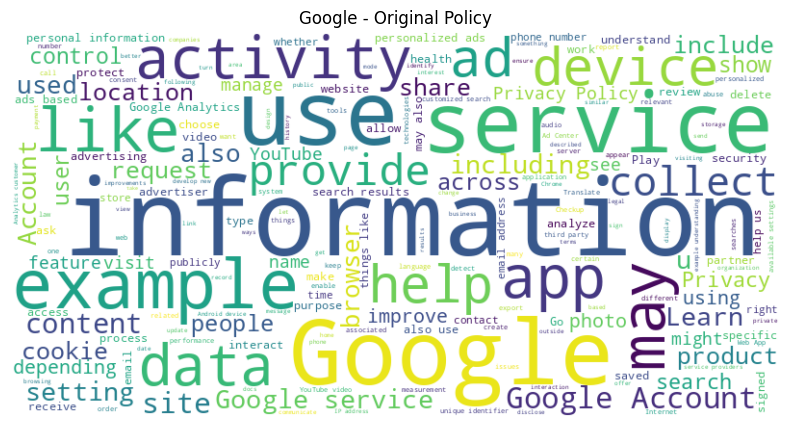

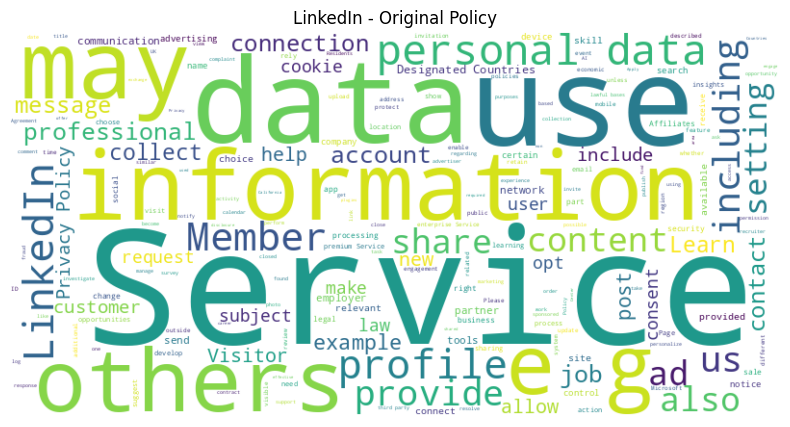

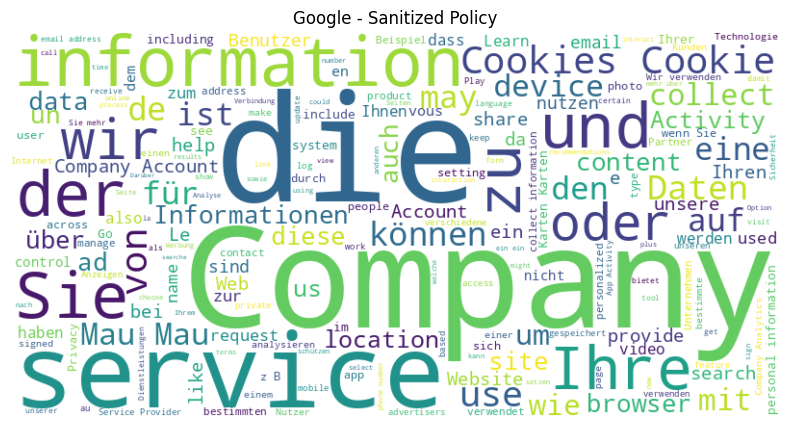

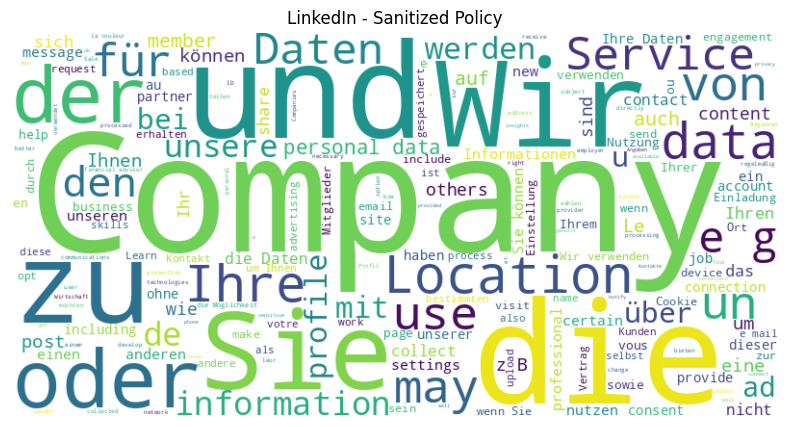

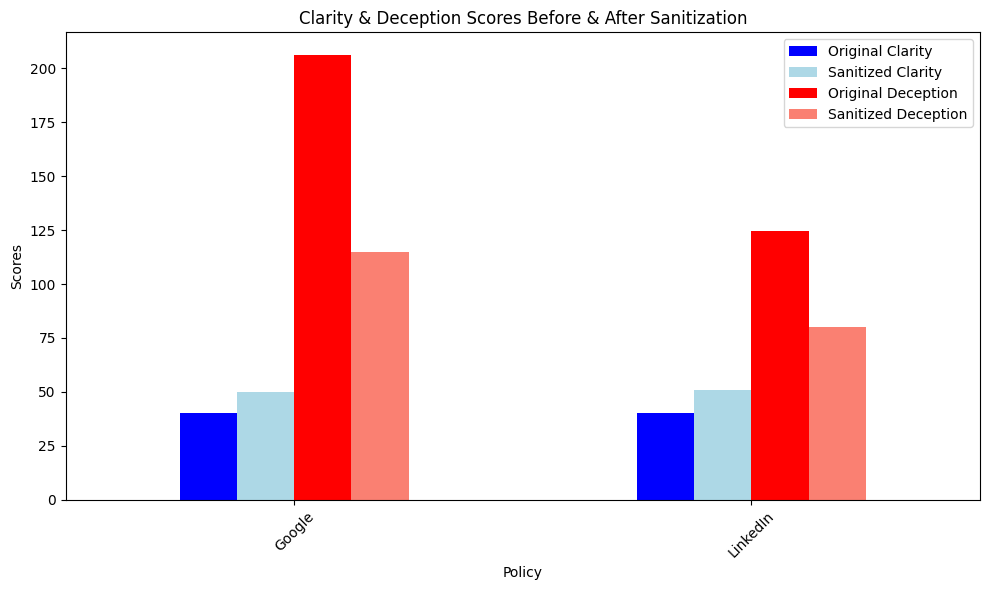

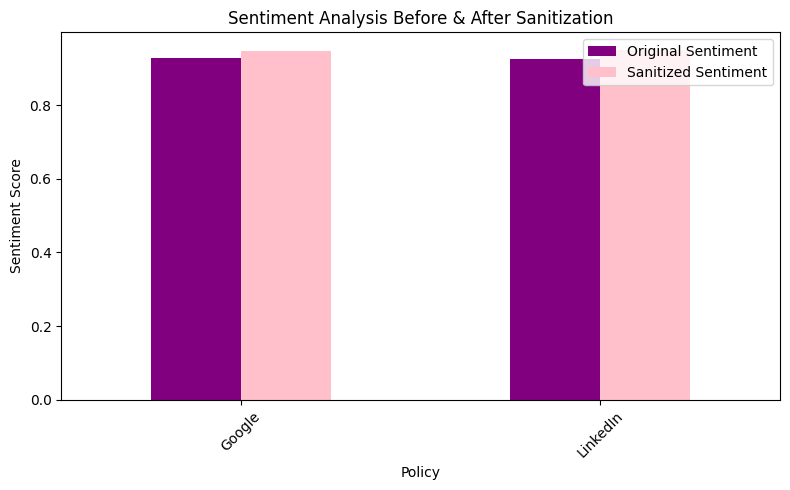

In [4]:
import requests
import re
import numpy as np
import nltk
import spacy
import matplotlib.pyplot as plt
import pandas as pd
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize
from wordcloud import WordCloud
from transformers import pipeline
import textstat
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from scipy.stats import laplace

# NLTK Data Path
nltk.data.path.append('/usr/local/nltk_data')
nltk.download('punkt_tab', download_dir='/usr/local/nltk_data')  # Fix the correct 'punkt' download
nltk.download('stopwords', download_dir='/usr/local/nltk_data')

# Load Stopwords
stopwords = set(stopwords.words("english"))

# NLP Models
nlp = spacy.load("en_core_web_sm")
sentiment_analyzer = pipeline("sentiment-analysis")
paraphraser = pipeline("text2text-generation", model="t5-small")  # Switched to smaller model to optimize performance
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Privacy Policies URLs
privacy_policy_urls = {
    "Google": "https://policies.google.com/privacy",
    "LinkedIn": "https://www.linkedin.com/legal/privacy-policy"
}

# Function to Extract Privacy Policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    return " ".join([p.get_text() for p in paragraphs]) if paragraphs else "Privacy Policy not found."

original_policies = {name: extract_privacy_policy(url) for name, url in privacy_policy_urls.items()}

# Named Entity Replacement for Privacy
def replace_named_entities(text):
    doc = nlp(text)
    modified_text = text
    for ent in doc.ents:
        if ent.label_ in ["ORG", "GPE"]:
            modified_text = modified_text.replace(ent.text, "The Company" if ent.label_ == "ORG" else "Your Location")
        elif ent.label_ in ["DATE", "TIME"]:
            modified_text = modified_text.replace(ent.text, "[Redacted]")
    return modified_text

# Exponential Mechanism for Differentially Private Paraphrasing
def dp_paraphrase_exponential(text, epsilon=1.0, num_paraphrases=3):
    sentences = sent_tokenize(text)
    paraphrased_sentences = []
    for sentence in sentences:
        if len(sentence.strip()) > 0:  # Avoid processing empty sentences
            paraphrases = paraphraser(sentence, max_length=60, num_return_sequences=num_paraphrases, do_sample=True)
            scores = np.array([textstat.flesch_reading_ease(p['generated_text']) for p in paraphrases])
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            chosen_paraphrase = np.random.choice([p['generated_text'] for p in paraphrases], p=probabilities)
            paraphrased_sentences.append(chosen_paraphrase)
        else:
            paraphrased_sentences.append(sentence)  # Retain original if empty sentence
    return " ".join(paraphrased_sentences)

# Differentially Private Deception Score
def dp_deception_score(text, epsilon=0.5):
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    noise = laplace.rvs(scale=1/epsilon)  # Laplace noise
    return clarity_score, deception_score + noise

# Sentiment Analysis
def calculate_sentiment(text):
    sentences = sent_tokenize(text)
    sentiment_scores = [sentiment_analyzer(sentence)[0]['score'] for sentence in sentences if len(sentence.strip()) > 0]
    return np.mean(sentiment_scores) if sentiment_scores else 0

# Generate Word Cloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800, height=400, background_color='white',
        stopwords=stopwords.union({"", "ENTITY"})
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Processing Privacy Policies
sanitized_policies = {}
scores_data = []

for name, original_text in original_policies.items():
    sanitized_text = replace_named_entities(original_text)
    sanitized_text = dp_paraphrase_exponential(sanitized_text, num_paraphrases=2)
    sanitized_policies[name] = sanitized_text

    original_clarity, original_deception = dp_deception_score(original_text)
    sanitized_clarity, sanitized_deception = dp_deception_score(sanitized_text)
    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
    })

# Output Results
scores_df = pd.DataFrame(scores_data)
print(scores_df)

# Visualization: Word Clouds
for name, text in original_policies.items():
    generate_wordcloud(text, f"{name} - Original Policy")
for name, text in sanitized_policies.items():
    generate_wordcloud(text, f"{name} - Sanitized Policy")

# Bar Chart: Clarity & Deception Scores
scores_df.set_index("Policy")[["Original Clarity", "Sanitized Clarity", "Original Deception", "Sanitized Deception"]].plot(
    kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon']
)
plt.ylabel("Scores")
plt.title("Clarity & Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar Chart: Sentiment Analysis
scores_df.set_index("Policy")[["Original Sentiment", "Sanitized Sentiment"]].plot(
    kind='bar', figsize=(8, 5), color=['purple', 'pink']
)
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [23]:
! pip install textstat

In [24]:
import requests
import numpy as np
import nltk
import spacy
import matplotlib.pyplot as plt
import pandas as pd
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud
from transformers import pipeline
import textstat
from nltk.corpus import wordnet, stopwords
from sentence_transformers import SentenceTransformer, util
import random



In [25]:
# Set up NLTK data path
nltk.data.path.append('/usr/local/nltk_data')
nltk.download('punkt_tab', download_dir='/usr/local/nltk_data')
nltk.download('stopwords', download_dir='/usr/local/nltk_data')
nltk.download('wordnet', download_dir='/usr/local/nltk_data')

# Load stopwords properly
nltk_stopwords = set(stopwords.words("english"))

# Initialize NLP models
nlp = spacy.load("en_core_web_sm")
sentiment_analyzer = pipeline("sentiment-analysis")
paraphraser = pipeline("text2text-generation", model="t5-base")
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')



[nltk_data] Downloading package punkt_tab to /usr/local/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/local/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/local/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0
Device set to use cuda:0


In [26]:
# Define privacy policy URLs
privacy_policy_urls = {
    "Google": "https://policies.google.com/privacy",
    "LinkedIn": "https://www.linkedin.com/legal/privacy-policy"
}

# Extract privacy policies
def extract_privacy_policy(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    paragraphs = soup.find_all("p")
    return " ".join([p.get_text() for p in paragraphs]) if paragraphs else "Privacy Policy text not found."

original_policies = {name: extract_privacy_policy(url) for name, url in privacy_policy_urls.items()}



In [27]:

# Replace named entities for privacy
def replace_named_entities(text):
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in ["ORG", "GPE"]:
            text = text.replace(ent.text, "The Company" if ent.label_ == "ORG" else "The Location")
        elif ent.label_ in ["DATE", "TIME", "DURATION"]:
            text = text.replace(ent.text, "")
    return text


In [28]:

# Exponential Mechanism for DP with Meaning Preservation
def dp_paraphrase_exponential(text, epsilon=1.0, num_paraphrases=5):
    sentences = sent_tokenize(text)
    paraphrased_sentences = []
    for sentence in sentences:
        paraphrases = paraphraser(sentence, max_length=50, num_return_sequences=num_paraphrases, do_sample=True)
        scores = np.array([textstat.flesch_reading_ease(p['generated_text']) for p in paraphrases])
        probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
        chosen_paraphrase = np.random.choice([p['generated_text'] for p in paraphrases], p=probabilities)

        # Ensure meaning is preserved
        similarity_score = util.pytorch_cos_sim(semantic_model.encode(sentence), semantic_model.encode(chosen_paraphrase))
        if similarity_score < 0.85:
            chosen_paraphrase = sentence  # Keep original if meaning changes too much

        paraphrased_sentences.append(chosen_paraphrase)
    return " ".join(paraphrased_sentences)



In [29]:
# Calculate clarity and deception scores
def calculate_deception_score(text):
    clarity_score = textstat.flesch_reading_ease(text)
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often", "generally", "typically", "occasionally", "some"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    total_words = len(word_tokenize(text))
    deception_score = ((100 - clarity_score) * 0.7) + ((vague_word_count / total_words) * 100 * 0.3)
    return clarity_score, deception_score



In [30]:
# Calculate sentiment analysis score
def calculate_sentiment(text, chunk_size=500):
    chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
    sentiment_scores = [sentiment_analyzer(chunk)[0]['score'] for chunk in chunks]
    return np.mean(sentiment_scores)

# Generate Word Cloud Comparison
def generate_wordcloud_comparison(original_text, sanitized_text, policy_name):
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    wordcloud_original = WordCloud(width=800, height=400, background_color='white').generate(original_text)
    wordcloud_sanitized = WordCloud(width=800, height=400, background_color='white').generate(sanitized_text)

    axs[0].imshow(wordcloud_original, interpolation='bilinear')
    axs[0].axis('off')
    axs[0].set_title(f"{policy_name} - Original")

    axs[1].imshow(wordcloud_sanitized, interpolation='bilinear')
    axs[1].axis('off')
    axs[1].set_title(f"{policy_name} - Sanitized")

    plt.show()

# Calculate semantic similarity
def calculate_similarity(original_text, sanitized_text):
    return util.pytorch_cos_sim(semantic_model.encode(original_text), semantic_model.encode(sanitized_text)).item()


In [31]:

# Apply sanitization & scoring
sanitized_policies = {}
scores_data = []

for name, original_text in original_policies.items():
    sanitized_text = replace_named_entities(original_text)
    sanitized_text = dp_paraphrase_exponential(sanitized_text, epsilon=1.0, num_paraphrases=1)
    sanitized_policies[name] = sanitized_text

    original_clarity, original_deception = calculate_deception_score(original_text)
    sanitized_clarity, sanitized_deception = calculate_deception_score(sanitized_text)
    original_sentiment = calculate_sentiment(original_text)
    sanitized_sentiment = calculate_sentiment(sanitized_text)
    similarity_score = calculate_similarity(original_text, sanitized_text)

    scores_data.append({
        "Policy": name,
        "Original Clarity": original_clarity,
        "Sanitized Clarity": sanitized_clarity,
        "Original Deception": original_deception,
        "Sanitized Deception": sanitized_deception,
        "Original Sentiment": original_sentiment,
        "Sanitized Sentiment": sanitized_sentiment,
        "Semantic Similarity": similarity_score  # ✅ New Column
    })

# Output scores in a DataFrame
scores_df = pd.DataFrame(scores_data)
print(scores_df)



     Policy  Original Clarity  Sanitized Clarity  Original Deception  \
0    Google             40.18              41.09           42.260815   
1  LinkedIn             40.08              40.89           42.280312   

   Sanitized Deception  Original Sentiment  Sanitized Sentiment  \
0            41.617122            0.944253             0.944579   
1            41.724614            0.939577             0.950791   

   Semantic Similarity  
0             0.893469  
1             0.654036  


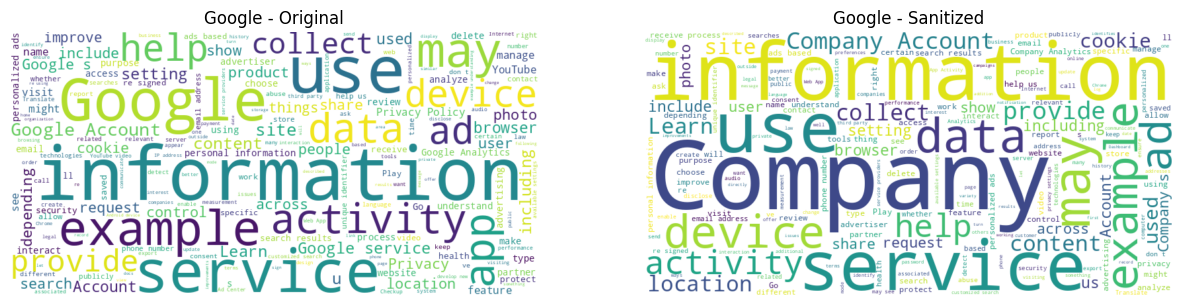

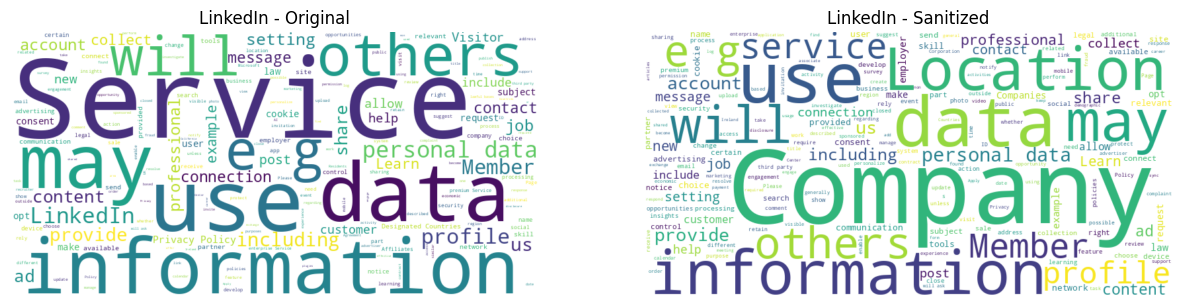

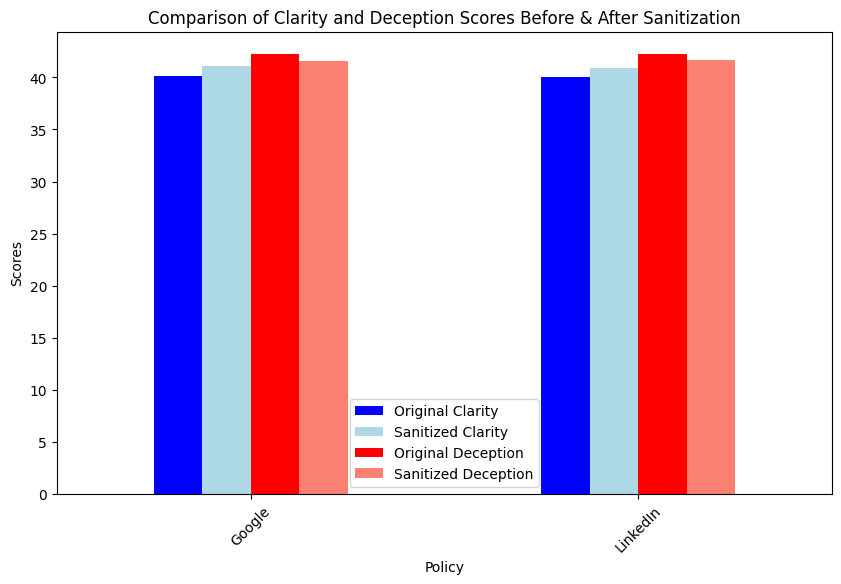

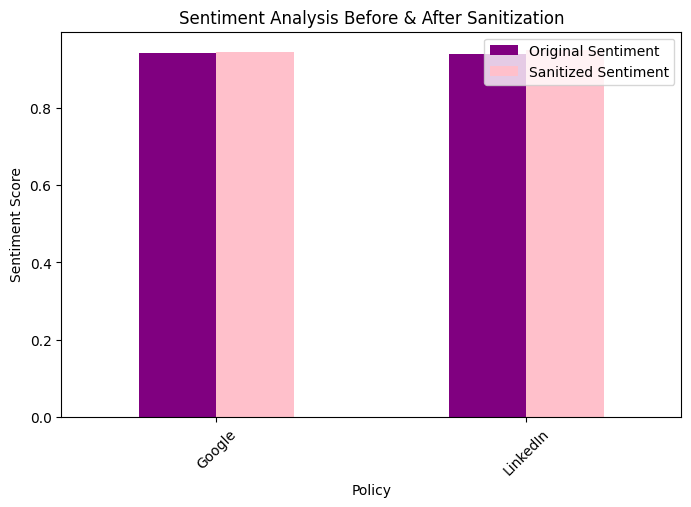

In [32]:
# Generate Word Cloud Comparisons
for name in original_policies.keys():
    generate_wordcloud_comparison(original_policies[name], sanitized_policies[name], name)

# Visualization: Clarity & Deception Score Comparison
scores_df.set_index("Policy")[["Original Clarity", "Sanitized Clarity", "Original Deception", "Sanitized Deception"]].plot(
    kind='bar', figsize=(10, 6), color=['blue', 'lightblue', 'red', 'salmon'])
plt.ylabel("Scores")
plt.title("Comparison of Clarity and Deception Scores Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()

# Visualization: Sentiment Analysis Comparison
scores_df.set_index("Policy")[["Original Sentiment", "Sanitized Sentiment"]].plot(
    kind='bar', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After Sanitization")
plt.xticks(rotation=45)
plt.show()